## Import Packages

In [ ]:
import numpy       as np
import pandas      as pd
import matplotlib.pyplot as plt
import pywt

## Load Data

In [ ]:
# Load data with column names
path = 'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/ML1/ExampleData?raw=true'
Data = pd.read_csv(path, sep=',',names=['time(s)', 'Acceleration(g)', 'Voltage(V)', 'Current(kA)'])
Data

,time(s),Acceleration(g),Voltage(V),Current(kA)
0,0.000000,0.016440,-0.014200,0.001433
1,0.000078,0.013822,-0.015707,0.001504
2,0.000156,0.019431,-0.016963,0.001433
3,0.000234,0.003726,-0.017248,0.001549
4,0.000313,0.022049,-0.009840,0.001864
...,...,...,...,...
2769,0.216330,0.077392,0.002404,0.003453
2770,0.216410,0.030276,0.003952,0.003498
2771,0.216480,0.017188,0.005504,0.003397
2772,0.216560,0.037754,-0.000108,0.003506


Confirm each signal by plotting

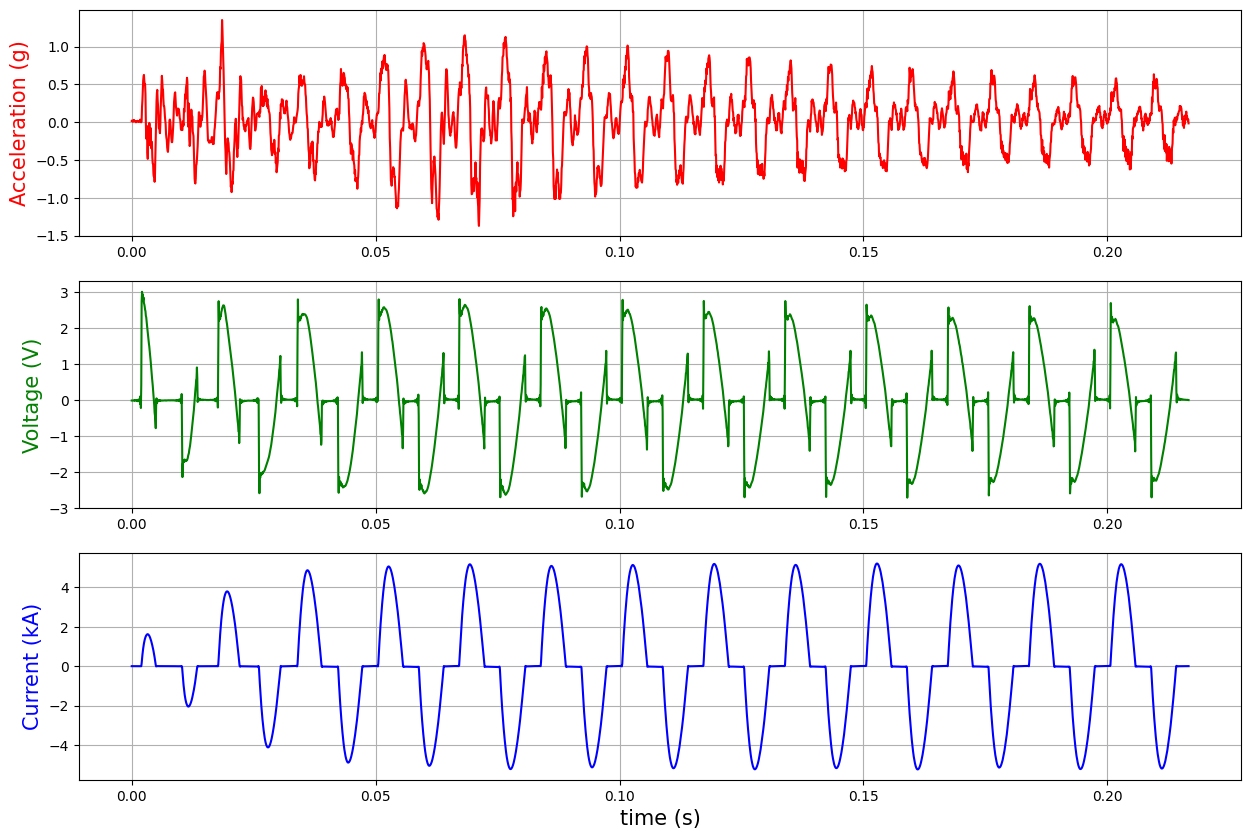

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(3,1,1) # Acceleration signal
plt.plot(Data.iloc[:,0] , Data.iloc[:,1], color='r')
plt.ylabel('Acceleration (g)', fontsize=15, color='r')
plt.grid()

plt.subplot(3,1,2) # Voltage signal
plt.plot(Data.iloc[:,0] , Data.iloc[:,2], color='g')
plt.ylabel('Voltage (V)', fontsize=15, color='g')
plt.grid()

plt.subplot(3,1,3) # Current signal
plt.plot(Data.iloc[:,0] , Data.iloc[:,3], color=[0,0,1])
plt.ylabel('Current (kA)',fontsize=15, color='b')
plt.xlabel('time (s)', fontsize=15)
plt.grid()

plt.show()

## Implementation of Wavelet Transform (WT)-based Signal Decomposition

### (1) Parameter setting for Wavelet Decomposition

In [ ]:
MotherWavelet = pywt.Wavelet('haar')   # Mother wavelet
Level         = 8                      # Wavelet levels

### (2) Wavelet Decomposition Implementation

* Extract coefficient signals for each frequency range

In [ ]:
Data_Target = Data.iloc[:,2] # Select one sensor signal
Coefficient = pywt.wavedec(Data_Target, MotherWavelet, level=Level, axis=0)
len(Coefficient)

9

In [ ]:
# Confirm extracted coefficients as DataFrame
Coefficient_df = pd.DataFrame(Coefficient)
Coefficient_df

,0,1,2,3,4,5,6,7,8,9,...,1377,1378,1379,1380,1381,1382,1383,1384,1385,1386
0,5.120951,1.975495,-1.842492,-4.195320,0.460655,4.873428,-0.044796,-2.117162,-3.416373,0.527733,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.692723,-9.590589,-9.121063,7.723327,11.645272,1.584408,-10.824891,-7.602848,6.532720,9.543499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.985119,-9.315771,6.774151,-1.827475,-5.975729,12.777754,-12.966999,9.843026,-1.071380,-6.587815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-2.667865,-0.041871,-5.320015,-8.285028,1.169623,-0.645522,-2.901291,8.230300,8.292544,-1.375463,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-3.089995,5.088295,-0.044425,0.005821,0.136213,0.272540,-0.002265,-1.014673,3.799572,-0.036177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.002355,-4.330047,1.483925,2.171621,-0.048522,-0.002625,0.000058,0.000712,1.764845,-1.069910,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,-0.009552,0.007996,-0.011065,-1.894130,0.413198,0.562008,0.713096,0.873990,-0.035148,-0.001600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.002152,-0.002364,-0.009133,-0.000549,-0.007395,0.003905,-2.773755,0.030250,0.122050,0.165600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.001066,0.000202,0.000872,-0.006484,-0.006208,0.001241,0.010198,0.022310,0.022992,0.000175,...,-0.001237,-0.003242,-0.001901,-0.000133,0.002293,0.001386,-0.000734,0.001479,-0.001098,0.001092


Confirm the sizes of each coefficient
* Time resolution gets higher for observing high frequency signals

In [ ]:
print('Size of a',Level, ' = ', len(Coefficient[0]))  # First coefficient : the lowest freqeuncy ragne

for i in range(1,Level+1):
    print('Size of d',Level+1-i , ' = ', len(Coefficient[i]))

Size of a 8  =  11
Size of d 8  =  11
Size of d 7  =  22
Size of d 6  =  44
Size of d 5  =  87
Size of d 4  =  174
Size of d 3  =  347
Size of d 2  =  694
Size of d 1  =  1387


### (3) Plotting of Wavelet Decompositiobn Result

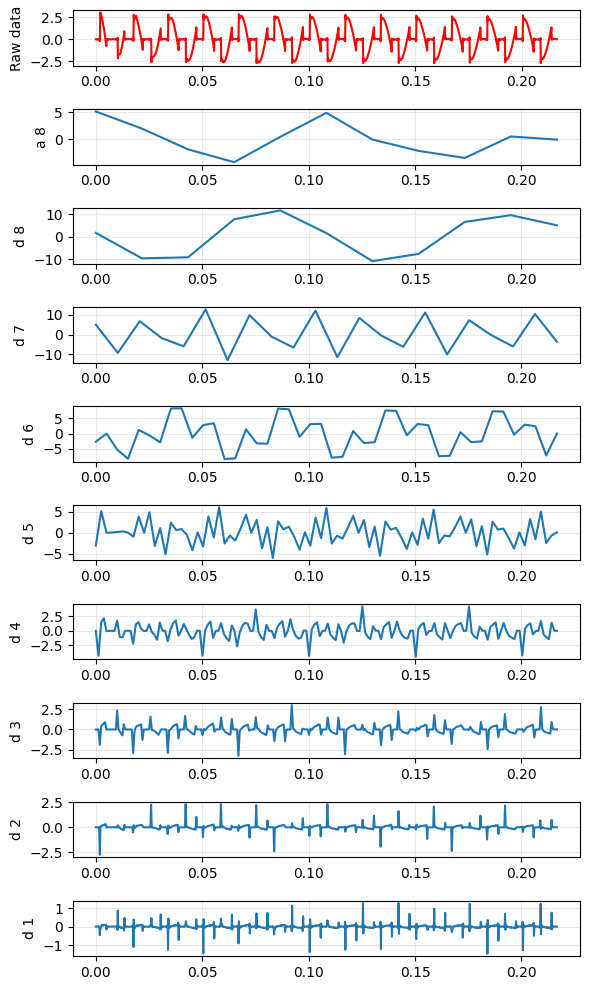

In [ ]:
plt.figure(figsize=(6,10))

plt.subplot(Level+2,1,1)    # Raw signal
plt.plot(Data.iloc[:,0], Data_Target, color='r')
plt.ylabel('Raw data')
plt.grid(alpha=0.3)

plt.subplot(Level+2,1,2)    # The lowest frequency range
Time_temp = np.arange( 0 , 0.2167 + 0.2167/(len(Coefficient[0])-1) , 0.2167/(len(Coefficient[0])-1) )
plt.plot(Time_temp , Coefficient[0])
plt.ylabel('a %d' %(Level))
plt.grid(alpha=0.3)

for k in range(1,Level+1):
    plt.subplot(Level+2,1,k+2)
    Time_temp = np.arange( 0 , 0.2167 + 0.2167/(len(Coefficient[k])-1) , 0.2167/(len(Coefficient[k])-1) )
    plt.plot(Time_temp , Coefficient[k])
    plt.ylabel('d %d'%(Level+1-k))
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()